In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from pathlib import Path
from tqdm import tqdm
import random

In [8]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Paths setup
base_drive_path = "/content/drive/MyDrive/DS_01_G03/OriginalDataset"
local_base = Path("/content/isic_raw")
os.makedirs(local_base, exist_ok=True)

In [10]:
classes = ["BCC", "MEL", "NV", "BKL"]

In [11]:
# Copy dataset to local environment for high-speed processing
for cls in classes:
    target_dir = local_base / cls
    print(f"Copying {cls} dataset...")
    os.makedirs(target_dir, exist_ok=True) # Ensure target directory exists
    source_dir = os.path.join(base_drive_path, cls)
    # Use rsync for more robust copying and to handle existing files, or use rm -rf before cp -r
    # For simplicity and to ensure overwrite, we'll stick to cp -r, but first remove contents.
    !rm -rf "{target_dir}"/*
    !cp -r "{source_dir}/." "{target_dir}/"
print("Dataset copying complete.")


Copying BCC dataset...
Copying MEL dataset...
Copying NV dataset...
Copying BKL dataset...
Dataset copying complete.


In [40]:
class PilotValidator:
    def __init__(self, blur_limit=7.5, bright_range=(70, 215), min_lesion_ratio=0.03):
        self.blur_limit = blur_limit
        self.bright_min, self.bright_max = bright_range
        self.min_lesion_ratio = min_lesion_ratio

    # 1. QUALITY CHECK
    def get_quality_status(self, img_bgr):
        # Brightness check
        yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
        avg_bright = np.mean(yuv[:, :, 0])

        if not (self.bright_min < avg_bright < self.bright_max):
            return False, "Lighting Issue"

        # Blur check
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

        if blur_score < self.blur_limit:
            return False, "Blurry/Noise"

        return True, "Passed Quality"

    # 2. HAIR REMOVAL
    def remove_hair(self, img):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

        _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

        clean_img = cv2.inpaint(img, hair_mask, 3, cv2.INPAINT_TELEA)
        return clean_img

    # 3. ADAPTIVE HSV SEGMENTATION
    def adaptive_hsv_mask(self, img):
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)

        # Adapt threshold using brightness
        v_mean = np.mean(v)

        # Ensure bounds are uint8 to avoid type mismatch with cv2.inRange
        lower_hsv = np.array([0, 30, 20], dtype=np.uint8)
        upper_v_val = int(max(120, min(200, v_mean))) # Ensure it's an integer
        upper_hsv = np.array([180, 255, upper_v_val], dtype=np.uint8)

        mask = cv2.inRange(hsv, lower_hsv, upper_hsv)
        return mask

    # 4. KEEP ONLY MAIN LESION
    def get_main_lesion(self, mask):
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            return mask, 0

        largest = max(contours, key=cv2.contourArea)

        clean_mask = np.zeros_like(mask)
        cv2.drawContours(clean_mask, [largest], -1, 255, -1)

        area = cv2.contourArea(largest)
        total = mask.shape[0] * mask.shape[1]
        ratio = area / total

        return clean_mask, ratio

    # 5. FULL SEGMENT PIPELINE
    def segment_hsv(self, img_bgr):
        # Resize
        h, w = img_bgr.shape[:2]
        img = cv2.resize(img_bgr, (500, int(h * (500.0 / w))))

        # Hair removal
        clean_img = self.remove_hair(img)

        # Adaptive HSV mask
        mask = self.adaptive_hsv_mask(clean_img)

        # Noise cleaning
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        # Keep main lesion only
        final_mask, ratio = self.get_main_lesion(mask)

        return clean_img, final_mask, ratio

    # 6. FINAL VALIDATION
    def validate(self, img_bgr):
        # Step 1: Quality check
        ok, msg = self.get_quality_status(img_bgr)
        if not ok:
            return False, msg, None, None

        # Step 2: Segmentation
        clean_img, mask, ratio = self.segment_hsv(img_bgr)

        # Step 3: Lesion size check
        if ratio < self.min_lesion_ratio:
            return False, "Low Lesion Area", clean_img, mask

        return True, "Valid Image", clean_img, mask

# Initialize
validator = PilotValidator()
local_base = Path("/content/isic_raw")
classes = ["BCC", "MEL", "NV", "BKL"]
pilot_results = []

In [41]:
print("--- STARTING PILOT TEST (25 images per class) ---")

pilot_results = [] # Initialize pilot_results list

training_img_path = "/content/skin_sample.jpg"
training_img = cv2.imread(training_img_path)

# Fallback for missing training image
if training_img is None:
    print(f"Error: Could not load training image from {training_img_path}. Please ensure the file exists and contains skin tones. Using a dummy image for now.")
    training_img = np.zeros((100, 100, 3), dtype=np.uint8)

for cls in classes:
    class_path = local_base / cls
    if not class_path.exists(): continue

    all_images = list(class_path.glob("*.jpg"))
    samples = random.sample(all_images, min(25, len(all_images)))

    for img_p in tqdm(samples, desc=f"Testing {cls}"):
        img = cv2.imread(str(img_p))
        if img is None: continue

        # 1. Quality Gate
        quality_ok, reason = validator.get_quality_status(img)

        status = "Rejected"
        lesion_ratio = 0

        if quality_ok:
            # 2. Segmentation Gate
            clean_img, mask, lesion_ratio = validator.segment_hsv(img)

            # 3. Check if lesion ratio meets minimum threshold
            if lesion_ratio >= validator.min_lesion_ratio:
                # Simplified logic: remove texture validation as it's not defined in the class
                status = "Accepted"
                reason = "Target Isolated"
            else:
                reason = "Low Lesion Contrast"

        pilot_results.append({
            "Class": cls,
            "Image": img_p.name,
            "Status": status,
            "Reason": reason,
            "Area_Ratio": round(lesion_ratio, 4)
        })

--- STARTING PILOT TEST (25 images per class) ---
Error: Could not load training image from /content/skin_sample.jpg. Please ensure the file exists and contains skin tones. Using a dummy image for now.


Testing BKL: 100%|██████████| 25/25 [00:02<00:00, 11.59it/s]



PILOT TEST SUMMARY (Total 100 Images)
Status  Accepted  Rejected
Class                     
BCC           21         4
BKL           17         8
MEL           21         4
NV            24         1

Detailed Rejection Reasons:
Reason
Blurry/Noise           3
Lighting Issue         5
Low Lesion Contrast    9
dtype: int64

Generating Visual Samples...


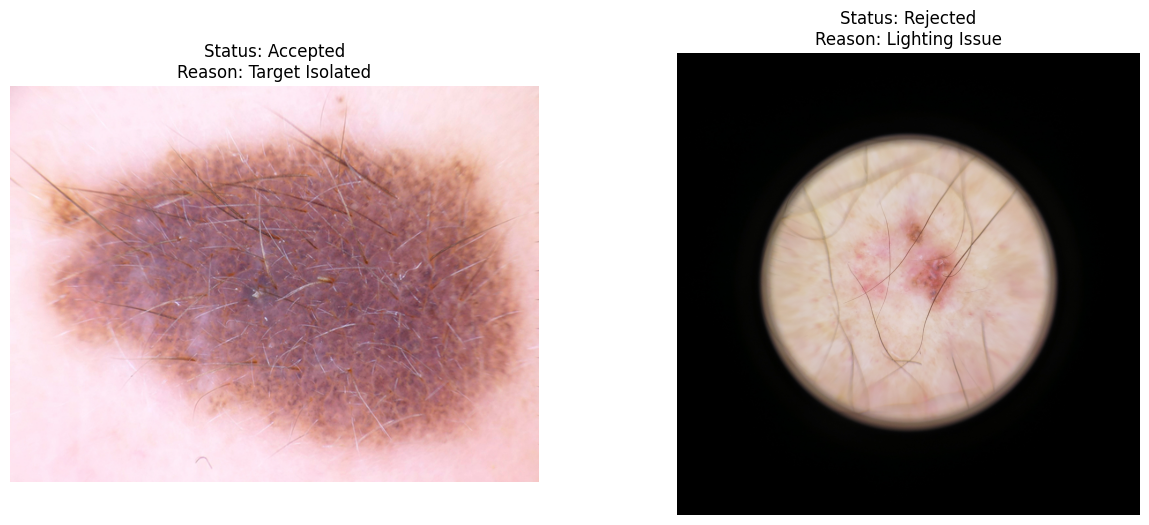

In [46]:
# Create DataFrame for results
df_pilot = pd.DataFrame(pilot_results)

# --- DISPLAY SUMMARY TABLE ---
print("\n" + "="*40)
print("PILOT TEST SUMMARY (Total 100 Images)")
print("="*40)

if df_pilot.empty:
    print("No pilot test data available. df_pilot is empty.")
    print("Please ensure that the dataset copying step (cell o78J6xnvGZa7) ran correctly and images are present in the local directories.")
else:
    summary = df_pilot.groupby(['Class', 'Status']).size().unstack(fill_value=0)
    print(summary)

    print("\nDetailed Rejection Reasons:")
    rejection_summary = df_pilot[df_pilot['Status'] == 'Rejected'].groupby('Reason').size()
    print(rejection_summary)

    # Display a few examples of Accepted vs Rejected
    print("\nGenerating Visual Samples...")
    plt.figure(figsize=(15, 6))
    for i, status in enumerate(['Accepted', 'Rejected']):
        subset = df_pilot[df_pilot['Status'] == status]
        if not subset.empty:
            sample_row = subset.sample(1).iloc[0]
            img_path = local_base / sample_row['Class'] / sample_row['Image']
            img = cv2.imread(str(img_path))

            plt.subplot(1, 2, i+1)
            plt.title(f"Status: {status}\nReason: {sample_row['Reason']}")
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
    plt.show()


In [45]:
# FULL DATASET EXECUTION

# 1. Initialize the Results list
full_dataset_results = []

print(f"--- STARTING FULL DATASET TEST ---")
print(f"Targeting all images in: {local_base}")

# 2. Loop through every class and every image
for cls in classes:
    class_path = local_base / cls
    if not class_path.exists():
        print(f"Directory {cls} not found, skipping...")
        continue

    # Get all .jpg files in the folder
    all_images = list(class_path.glob("*.jpg"))

    # Use tqdm to show a progress bar for the whole class
    for img_p in tqdm(all_images, desc=f"Processing {cls}"):
        img = cv2.imread(str(img_p))
        if img is None:
            continue

        # 1. Quality Gate
        quality_ok, reason = validator.get_quality_status(img)

        status = "Rejected"
        lesion_ratio = 0

        if quality_ok:
            # 2. Segmentation Gate (HSV Color Masking with multiple ranges)
            clean_img, mask, lesion_ratio = validator.segment_hsv(img)

            # Check if the segmented lesion area is large enough
            if lesion_ratio >= validator.min_lesion_ratio:
                # Simplified logic: removed texture validation as it's not defined in the class
                status = "Accepted"
                reason = "Target Isolated"
            else:
                reason = "Low Lesion Contrast"

        # Collect data
        full_dataset_results.append({
            "Class": cls,
            "Image": img_p.name,
            "Status": status,
            "Reason": reason,
            "Area_Ratio": round(lesion_ratio, 4)
        })

--- STARTING FULL DATASET TEST ---
Targeting all images in: /content/isic_raw


Processing BKL: 100%|██████████| 2624/2624 [03:14<00:00, 13.48it/s]


In [47]:
# 3. Create Final DataFrame
df_full = pd.DataFrame(full_dataset_results)

# 4. Save to CSV for project documentation
csv_filename = "full_dataset_segmentation_report.csv"
df_full.to_csv(csv_filename, index=False)

In [49]:
# FINAL SUMMARY REPORT

print("\n" + "="*50)
print("FINAL DATASET SUMMARY REPORT")
print("="*50)

# Acceptance rates per class
final_summary = df_full.groupby(['Class', 'Status']).size().unstack(fill_value=0)
print("\nAcceptance vs Rejection Counts:")
print(final_summary)

# Breakdown of rejection reasons across the whole dataset
print("\nGlobal Rejection Breakdown:")
print(df_full[df_full['Status'] == 'Rejected']['Reason'].value_counts())

print(f"\nSuccess! Full report saved as: {csv_filename}")


FINAL DATASET SUMMARY REPORT

Acceptance vs Rejection Counts:
Status  Accepted  Rejected
Class                     
BCC         2730       593
BKL         2316       308
MEL         3991       531
NV         11523      1352

Global Rejection Breakdown:
Reason
Low Lesion Contrast    1749
Lighting Issue          846
Blurry/Noise            189
Name: count, dtype: int64

Success! Full report saved as: full_dataset_segmentation_report.csv



Generating final visualization of accepted lesions...


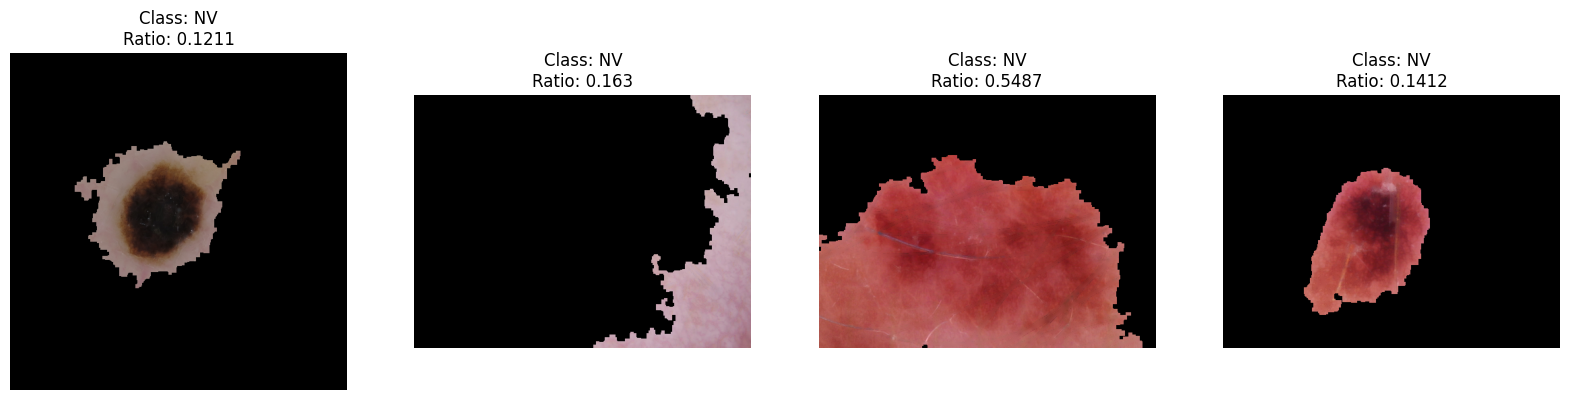

In [50]:
# Visualize 4 random Accepted images from the full run
print("\nGenerating final visualization of accepted lesions...")
accepted_df = df_full[df_full['Status'] == 'Accepted']
if not accepted_df.empty:
    plt.figure(figsize=(20, 5))
    samples = accepted_df.sample(min(4, len(accepted_df)))
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = local_base / row['Class'] / row['Image']
        clean_img, mask, ratio = validator.segment_hsv(cv2.imread(str(img_path)))
        isolated = cv2.bitwise_and(clean_img, clean_img, mask=mask)

        plt.subplot(1, 4, i+1)
        plt.title(f"Class: {row['Class']}\nRatio: {row['Area_Ratio']}")
        plt.imshow(cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB))
        plt.axis('off')
    plt.show()


VALIDATOR ACCURACY REPORT
Total Images: 23344
Total Accepted: 20560
Overall Accuracy: 88.07%

Accuracy per Class:
Class
BCC    82.154680
BKL    88.262195
MEL    88.257408
NV     89.499029
dtype: float64


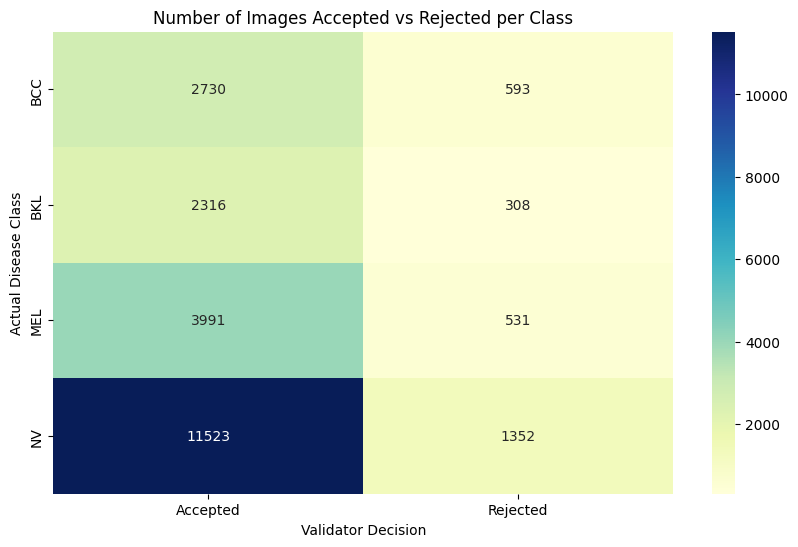

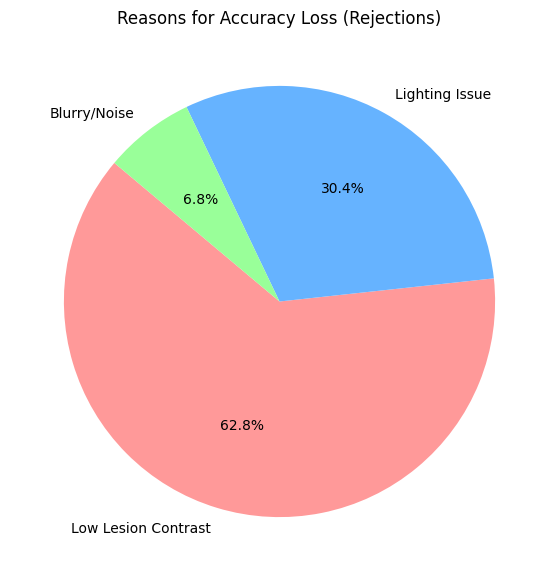


--- Summary ---
Highest Accuracy: NV (89.50%)
Lowest Accuracy: BCC (82.15%)


In [51]:
# Accuracy and Performance Report

import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*50)
print("VALIDATOR ACCURACY REPORT")
print("="*50)

# 1. Overall Pass Rate (Accuracy)
total_images = len(df_full)
accepted_count = len(df_full[df_full['Status'] == 'Accepted'])
overall_accuracy = (accepted_count / total_images) * 100

print(f"Total Images: {total_images}")
print(f"Total Accepted: {accepted_count}")
print(f"Overall Accuracy: {overall_accuracy:.2f}%")

# 2. Accuracy per Class (Fixed to remove DeprecationWarning)
# We add 'include_groups=False' to follow the new Pandas standard
class_accuracy = df_full.groupby('Class').apply(
    lambda x: (x['Status'] == 'Accepted').sum() / len(x) * 100,
    include_groups=False
)

print("\nAccuracy per Class:")
print(class_accuracy)

# 3. Decision Heatmap (Visualizing Accepted vs Rejected)
plt.figure(figsize=(10, 6))
summary_counts = df_full.groupby(['Class', 'Status']).size().unstack(fill_value=0)
sns.heatmap(summary_counts, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Number of Images Accepted vs Rejected per Class")
plt.ylabel("Actual Disease Class")
plt.xlabel("Validator Decision")
plt.show()

# 4. Rejection Reason Analysis
plt.figure(figsize=(7, 7))
rejection_reasons = df_full[df_full['Status'] == 'Rejected']['Reason'].value_counts()
rejection_reasons.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Reasons for Accuracy Loss (Rejections)")
plt.ylabel("") # Removes the 'Reason' label from the side
plt.show()

print("\n--- Summary ---")
print(f"Highest Accuracy: {class_accuracy.idxmax()} ({class_accuracy.max():.2f}%)")
print(f"Lowest Accuracy: {class_accuracy.idxmin()} ({class_accuracy.min():.2f}%)")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


--- Running Negative Test on 8 Images ---


100%|██████████| 8/8 [00:03<00:00,  2.11it/s]


,File,Result,Reason,Lesion Ratio
0,test 1.jpg,PASS (Correct Rejection),No Lesion Color Found,0.0000
1,test 2.jpg,PASS (Correct Rejection),No Lesion Color Found,0.0000
2,test 3.jpg,PASS (Correct Rejection),Lighting Issue (avg brightness: 25.1),0.0262
3,test 4.jpg,FAIL (False Positive),Mistakenly identified as Lesion,0.2307
4,test 6.jpg,PASS (Correct Rejection),No Lesion Color Found,0.0204
5,test 7.jpg,PASS (Correct Rejection),No Lesion Color Found,0.0300
6,test 8.jpg,PASS (Correct Rejection),No Lesion Color Found,0.0000
7,test 5.jpeg,PASS (Correct Rejection),No Lesion Color Found,0.0000


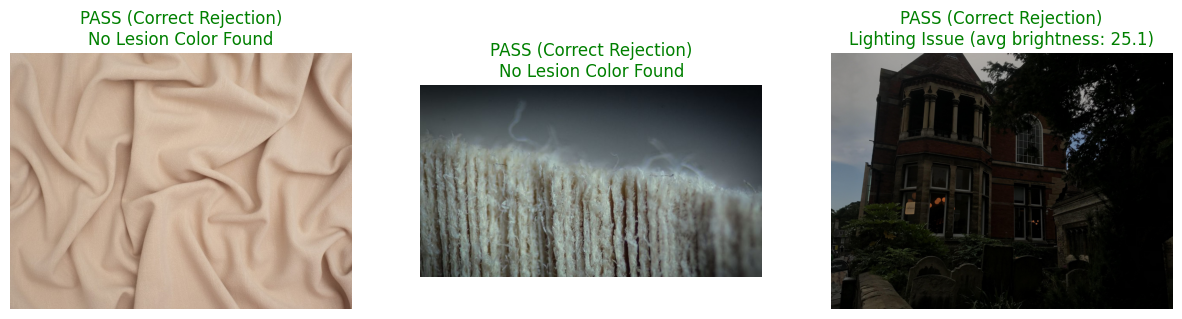

In [35]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

class PilotValidator:
    def __init__(self,
                 blur_limit=7.5,
                 bright_range=(70, 215),
                 min_lesion_ratio=0.07,          # increased from 0.02
                 min_circularity=0.25):          # optional shape filter
        self.blur_limit = blur_limit
        self.bright_min, self.bright_max = bright_range
        self.min_lesion_ratio = min_lesion_ratio
        self.min_circularity = min_circularity  # lower = more permissive

    def get_quality_status(self, img_bgr):
        """Checks for Brightness and Blur."""
        if img_bgr is None or img_bgr.size == 0:
            return False, "Invalid Image"

        # 1. Brightness Check (Y channel in YUV)
        yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
        avg_bright = np.mean(yuv[:,:,0])
        if not (self.bright_min < avg_bright < self.bright_max):
            return False, f"Lighting Issue (avg brightness: {avg_bright:.1f})"

        # 2. Blur Check
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        if blur_score < self.blur_limit:
            return False, f"Blurry/Noise (variance: {blur_score:.1f})"

        return True, "Passed Quality"

    def segment_hsv(self, img_bgr):
        """Performs hair removal and improved HSV segmentation for lesions."""
        if img_bgr is None or img_bgr.size == 0:
            return None, None, 0.0

        # Resize for consistent processing speed & results
        h, w = img_bgr.shape[:2]
        target_width = 500
        scale = target_width / w
        img = cv2.resize(img_bgr, (target_width, int(h * scale)))

        # DullRazor Hair Removal (unchanged)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)  # corrected name
        _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
        clean_img = cv2.inpaint(img, hair_mask, 3, cv2.INPAINT_TELEA)

        # HSV conversion
        hsv = cv2.cvtColor(clean_img, cv2.COLOR_BGR2HSV)

        # Tighter, lesion-focused HSV range (brown/red pigmented areas)
        lower_lesion = np.array([0,   50,  40])   # H:0-25 brown/red, S>50, V>40
        upper_lesion = np.array([25, 255, 210])

        mask = cv2.inRange(hsv, lower_lesion, upper_lesion)

        # Additional constraints: require decent saturation & brightness
        s_channel = hsv[:,:,1]
        v_channel = hsv[:,:,2]

        sat_mask = (s_channel >= 60).astype(np.uint8) * 255
        val_mask = (v_channel >= 50).astype(np.uint8) * 255

        # Combine: only keep areas that are both in range AND saturated AND bright enough
        mask = cv2.bitwise_and(mask, sat_mask)
        mask = cv2.bitwise_and(mask, val_mask)

        # Morphological refinement
        m_kernel = np.ones((7, 7), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, m_kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, m_kernel)   # remove small noise

        # Calculate ratio
        total_pixels = mask.shape[0] * mask.shape[1]
        lesion_pixels = np.count_nonzero(mask)
        ratio = lesion_pixels / total_pixels if total_pixels > 0 else 0.0

        # Optional: reject very non-round / rectangular shapes (helps with tables/chairs)
        if ratio >= self.min_lesion_ratio * 0.7:  # only check if close to passing
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                largest = max(contours, key=cv2.contourArea)
                area = cv2.contourArea(largest)
                perimeter = cv2.arcLength(largest, True)
                if perimeter > 0:
                    circularity = 4 * np.pi * area / (perimeter ** 2)
                    if circularity < self.min_circularity:
                        ratio = 0.0  # force reject non-lesion-like shapes

        return clean_img, mask, ratio

# Initialize validator instance
validator = PilotValidator()

# 1. THE TESTING FUNCTION

def perform_negative_test(folder_path, validator_instance):
    """
    Tests if the validator correctly rejects non-skin images.
    """
    path = Path(folder_path)
    if not path.exists():
        print(f"Error: Folder not found at {folder_path}")
        return None

    # Supported image formats
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']
    image_files = []
    for ext in extensions:
        image_files.extend(list(path.glob(ext)))

    if len(image_files) == 0:
        print("No images found in the specified folder.")
        return None

    print(f"--- Running Negative Test on {len(image_files)} Images ---")
    results = []

    for img_p in tqdm(image_files):
        img = cv2.imread(str(img_p))
        if img is None: continue

        # Step 1: Quality Check (Blur/Brightness)
        q_ok, q_reason = validator_instance.get_quality_status(img)

        # Step 2: Segmentation Check (HSV Masking)
        # Even if quality passes, HSV should fail to find a "lesion"
        clean_img, mask, ratio = validator_instance.segment_hsv(img)

        # Logic: If it passes quality AND finds a lesion, it's a False Positive (Bad)
        # If it is rejected by either gate, it's a Correct Rejection (Good)
        if q_ok and ratio >= validator_instance.min_lesion_ratio:
            status = "FAIL (False Positive)"
            final_reason = "Mistakenly identified as Lesion"
        else:
            status = "PASS (Correct Rejection)"
            final_reason = q_reason if not q_ok else "No Lesion Color Found"

        results.append({
            "File": img_p.name,
            "Result": status,
            "Reason": final_reason,
            "Lesion Ratio": round(ratio, 4)
        })

    return pd.DataFrame(results)

# 2. EXECUTION
MY_NON_SKIN_FOLDER = "/content/drive/MyDrive/TestImages"

# Run the test
df_neg_results = perform_negative_test(MY_NON_SKIN_FOLDER, validator)

# 3. DISPLAY RESULTS
if df_neg_results is not None:
    display(df_neg_results)

    # Visual Verification
    plt.figure(figsize=(15, 5))
    for i, row in df_neg_results.head(3).iterrows():
        img_path = Path(MY_NON_SKIN_FOLDER) / row['File']
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        plt.subplot(1, 3, i+1)
        color = 'green' if "PASS" in row['Result'] else 'red'
        plt.title(f"{row['Result']}\n{row['Reason']}", color=color)
        plt.imshow(img)
        plt.axis('off')
    plt.show()


--- Running Negative Test on 7 Images ---


100%|██████████| 7/7 [00:02<00:00,  3.19it/s]


,File,Result,Reason,Lesion Ratio
0,1.jpg,PASS (Correct Rejection),No Lesion Color Found,0.0000
1,3.jpg,PASS (Correct Rejection),Lighting Issue (avg=230.9),0.1554
2,2.jpg,FAIL (False Positive),Mistakenly identified as Lesion,0.2746
3,ISIC_0000016.jpg,FAIL (False Positive),Mistakenly identified as Lesion,0.0800
4,ISIC_0024799.jpg,PASS (Correct Rejection),No Lesion Color Found,0.0000
5,ISIC_0012492_downsampled.jpg,FAIL (False Positive),Mistakenly identified as Lesion,0.9666
6,ISIC_0000161.jpg,PASS (Correct Rejection),No Lesion Color Found,0.0000


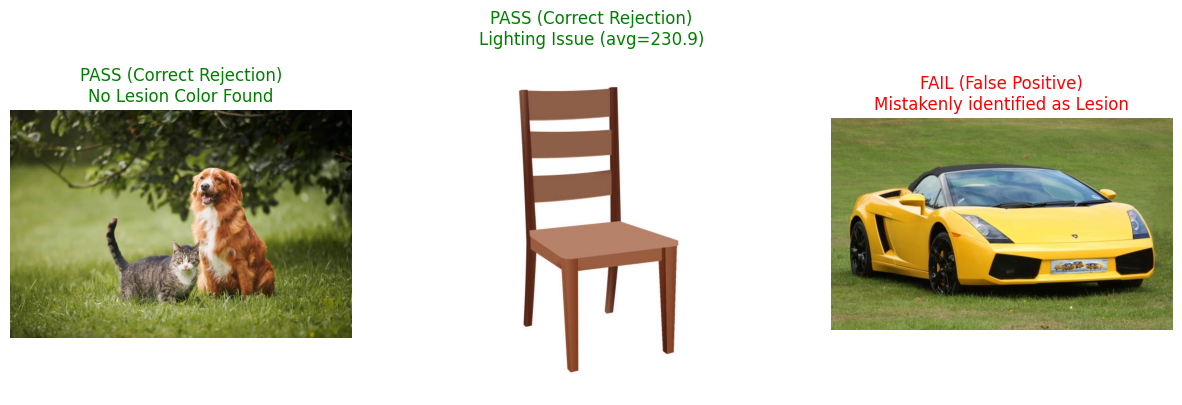

In [34]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

class PilotValidator:
    def __init__(self,
                 blur_limit=7.5,
                 bright_range=(65, 230),
                 min_lesion_ratio=0.06):          # balanced value
        self.blur_limit = blur_limit
        self.bright_min, self.bright_max = bright_range
        self.min_lesion_ratio = min_lesion_ratio

    def get_quality_status(self, img_bgr):
        if img_bgr is None or img_bgr.size == 0:
            return False, "Invalid Image"

        yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
        avg_bright = np.mean(yuv[:,:,0])
        if not (self.bright_min < avg_bright < self.bright_max):
            return False, f"Lighting Issue (avg={avg_bright:.1f})"

        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
        if blur_score < self.blur_limit:
            return False, f"Blurry (var={blur_score:.1f})"

        return True, "Passed Quality"

    def segment_hsv(self, img_bgr):
        if img_bgr is None or img_bgr.size == 0:
            return None, None, 0.0

        # Resize
        h, w = img_bgr.shape[:2]
        img = cv2.resize(img_bgr, (500, int(h * 500 / w)))

        # Hair removal
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
        _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
        clean_img = cv2.inpaint(img, hair_mask, 3, cv2.INPAINT_TELEA)

        hsv = cv2.cvtColor(clean_img, cv2.COLOR_BGR2HSV)

        # Balanced range for real lesions (brown/red/pink)
        lower = np.array([0, 35, 30])
        upper = np.array([35, 255, 235])
        mask = cv2.inRange(hsv, lower, upper)

        # Saturation + Value filter
        sat_mask = (hsv[:,:,1] >= 38).astype(np.uint8) * 255
        val_mask = (hsv[:,:,2] >= 35).astype(np.uint8) * 255
        mask = cv2.bitwise_and(mask, sat_mask)
        mask = cv2.bitwise_and(mask, val_mask)

        # Morphology
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7,7), np.uint8))

        # Ratio
        total = mask.shape[0] * mask.shape[1]
        lesion_px = np.count_nonzero(mask)
        ratio = lesion_px / total if total > 0 else 0.0

        # === NEW: TEXTURE REJECTION (this kills wood, fabric, fur) ===
        if ratio >= 0.03:                     # only check if mask is big enough
            masked_gray = cv2.bitwise_and(gray, gray, mask=mask)
            masked_pixels = masked_gray[mask > 0]
            if len(masked_pixels) > 100:
                texture_std = np.std(masked_pixels)
                if texture_std > 35:          # wood/fabric/fur have high variance
                    ratio = 0.0               # REJECT

        # Ignore very small blobs (noise)
        if ratio > 0 and lesion_px < (total * 0.02):
            ratio = 0.0

        return clean_img, mask, ratio

# Initialize validator instance
validator = PilotValidator()

# 1. THE TESTING FUNCTION

def perform_negative_test(folder_path, validator_instance):
    """
    Tests if the validator correctly rejects non-skin images.
    """
    path = Path(folder_path)
    if not path.exists():
        print(f"Error: Folder not found at {folder_path}")
        return None

    # Supported image formats
    extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']
    image_files = []
    for ext in extensions:
        image_files.extend(list(path.glob(ext)))

    if len(image_files) == 0:
        print("No images found in the specified folder.")
        return None

    print(f"--- Running Negative Test on {len(image_files)} Images ---")
    results = []

    for img_p in tqdm(image_files):
        img = cv2.imread(str(img_p))
        if img is None: continue

        # Step 1: Quality Check (Blur/Brightness)
        q_ok, q_reason = validator_instance.get_quality_status(img)

        # Step 2: Segmentation Check (HSV Masking)
        # Even if quality passes, HSV should fail to find a "lesion"
        clean_img, mask, ratio = validator_instance.segment_hsv(img)

        # Logic: If it passes quality AND finds a lesion, it's a False Positive (Bad)
        # If it is rejected by either gate, it's a Correct Rejection (Good)
        if q_ok and ratio >= validator_instance.min_lesion_ratio:
            status = "FAIL (False Positive)"
            final_reason = "Mistakenly identified as Lesion"
        else:
            status = "PASS (Correct Rejection)"
            final_reason = q_reason if not q_ok else "No Lesion Color Found"

        results.append({
            "File": img_p.name,
            "Result": status,
            "Reason": final_reason,
            "Lesion Ratio": round(ratio, 4)
        })

    return pd.DataFrame(results)

# 2. EXECUTION
MY_NON_SKIN_FOLDER = "/content/drive/MyDrive/Test2"

# Run the test
df_neg_results = perform_negative_test(MY_NON_SKIN_FOLDER, validator)

# 3. DISPLAY RESULTS
if df_neg_results is not None:
    display(df_neg_results)

    # Visual Verification
    plt.figure(figsize=(15, 5))
    for i, row in df_neg_results.head(3).iterrows():
        img_path = Path(MY_NON_SKIN_FOLDER) / row['File']
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        plt.subplot(1, 3, i+1)
        color = 'green' if "PASS" in row['Result'] else 'red'
        plt.title(f"{row['Result']}\n{row['Reason']}", color=color)
        plt.imshow(img)
        plt.axis('off')
    plt.show()
